In [1]:
# Enable automatic reloading of modules before executing code
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
import seaborn as sns

import matplotlib.patches as patches
import matplotlib.colors as mcolors

In [8]:
import utils as ut

# Hold-Out Accuracy

In [43]:
df_plt = pd.read_csv("data/dataframes-plotting-ms/accuracy-over-ndim.csv")
with open("data/dataframes-plotting-ms/accuracy-over-ndim-legend.pkl", "rb") as f:
    legend_dict = pickle.load(f)

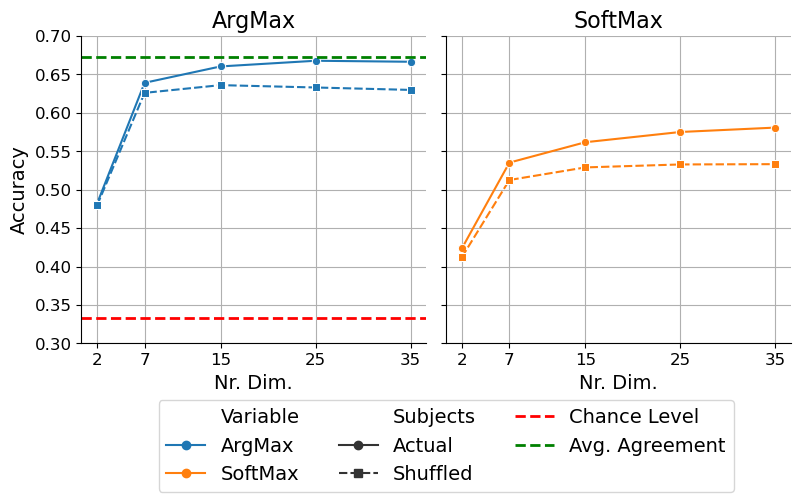

In [54]:
df_plt2 = df_plt.groupby(["md", "Subjects", "Nr. Dim.", "Variable"])["Accuracy"].max().reset_index()

g = sns.relplot(
    data=df_plt2, 
    x='Nr. Dim.', y='Accuracy', style = "Subjects", col="Variable", height=4,
    hue="Variable", marker="o", aspect=1, kind="line", markers=marker_styles, legend=False
)
g.set_titles("{col_name}")
g = plot_holdout_accuracy(g, legend_dict)

g.savefig("documents/writeup/figures-plotting/accuracy-benefit-over-dimensions.pdf")

# Split-Half Reliabilities

In [16]:
df_splithalf_summary_long = pd.read_csv("data/dataframes-plotting-ms/splithalf-reliabilities-1.csv")
df_corrs = pd.read_csv("data/dataframes-plotting-ms/splithalf-reliabilities-2.csv")

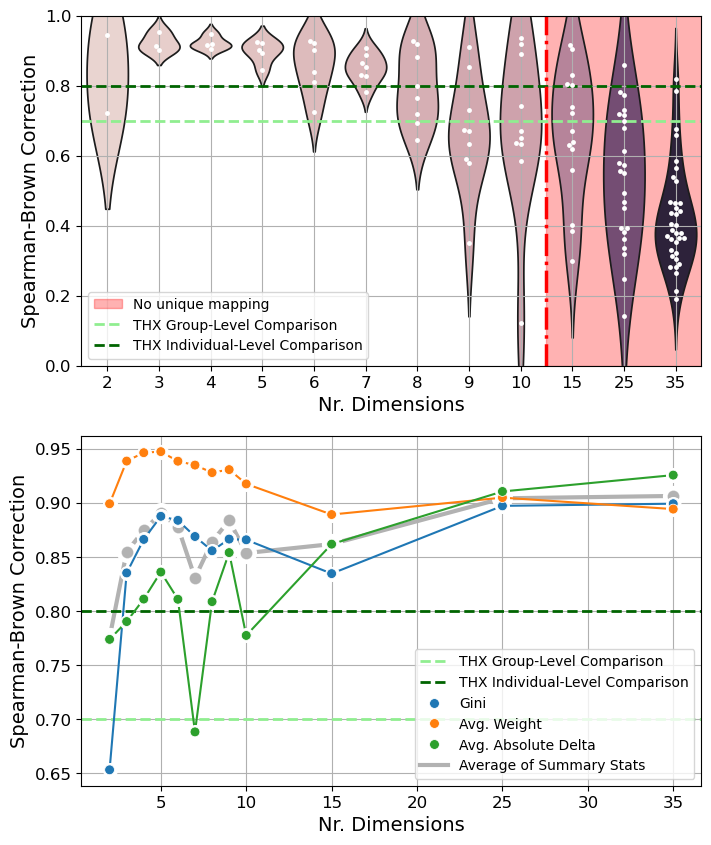

In [18]:
f, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 10))
f, axes = ut.reliabilities_over_dimensionalities(df_splithalf_summary_long, df_corrs, f, axes)

f.savefig("documents/writeup/figures-plotting/splithalf-reliability.pdf")

# D35

## Correlations Demographics & Questionnaires

In [3]:
df_qs_num_hm = pd.read_csv("data/dataframes-plotting-ms/qs-dems-correlations.csv")

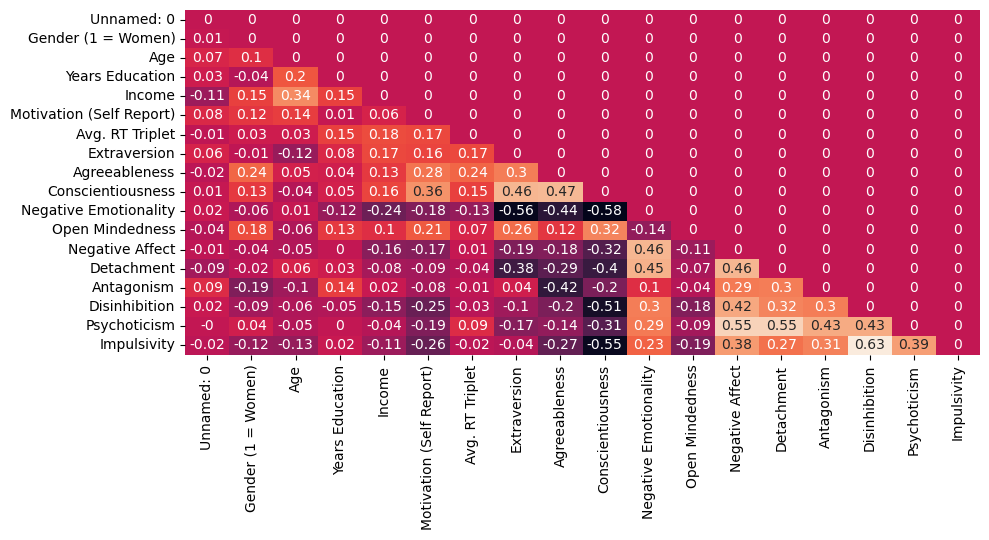

In [4]:
f, ax = plt.subplots(1, figsize=(10, 5.5))

df_hm = pd.DataFrame(np.tril(np.round(np.corrcoef(df_qs_num_hm.transpose()), 2), k=-1))
df_hm.columns = df_qs_num_hm.columns
df_hm.index = df_qs_num_hm.columns
sns.heatmap(df_hm, annot=True, ax=ax, cbar=False)

_ = plt.tight_layout()
f.savefig("documents/writeup/figures-plotting/heatmap-no-dimensional-weights.pdf")

## Correlations Summary Stats

In [6]:
df_corr_weight = pd.read_csv("data/dataframes-plotting-ms/avgweight-cors-d35.csv")
df_corr_weight_change = pd.read_csv("data/dataframes-plotting-ms/weightconsistency-cors-d35.csv")
df_corr_gini = pd.read_csv("data/dataframes-plotting-ms/gini-cors-d35.csv")

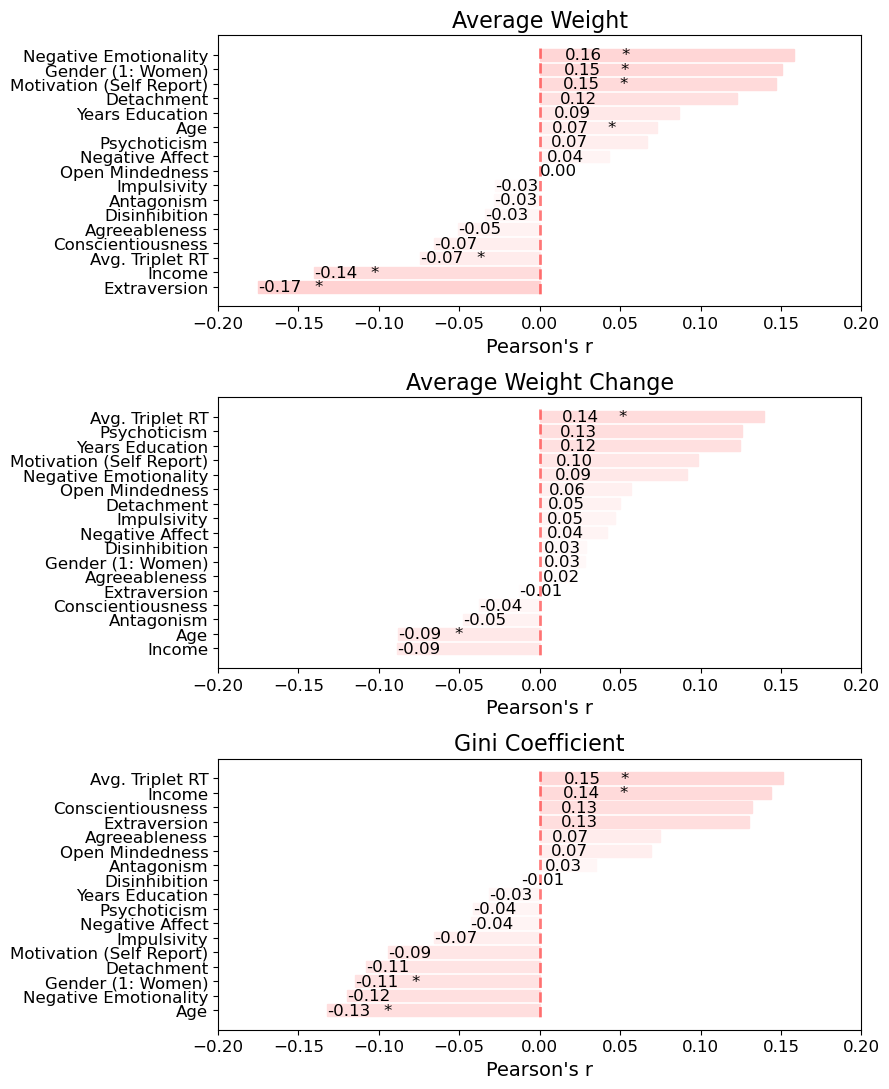

In [9]:
f_all, axes = plt.subplots(nrows=3, figsize=(9, 11))
ut.barplot_cols(df_corr_weight.query("var not in ['idx']").copy(), "Average Weight", f_all, axes[0])
ut.barplot_cols(df_corr_weight_change.query("var not in ['idx']").copy(), "Average Weight Change", f_all, axes[1])
ut.barplot_cols(df_corr_gini.query("var not in ['idx']").copy(), "Gini Coefficient", f_all, axes[2])
plt.tight_layout()
f_all.savefig("documents/writeup/figures-plotting/summarystats-correlations-35d.pdf")

# All Dimensionalities

In [13]:
df_plt = pd.read_csv("data/dataframes-plotting-ms/correlations-alldims.csv")

/tmp/ipykernel_3043070/3669343139.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(wrapped_labels)
/tmp/ipykernel_3043070/3669343139.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(wrapped_labels)
/tmp/ipykernel_3043070/3669343139.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(wrapped_labels)


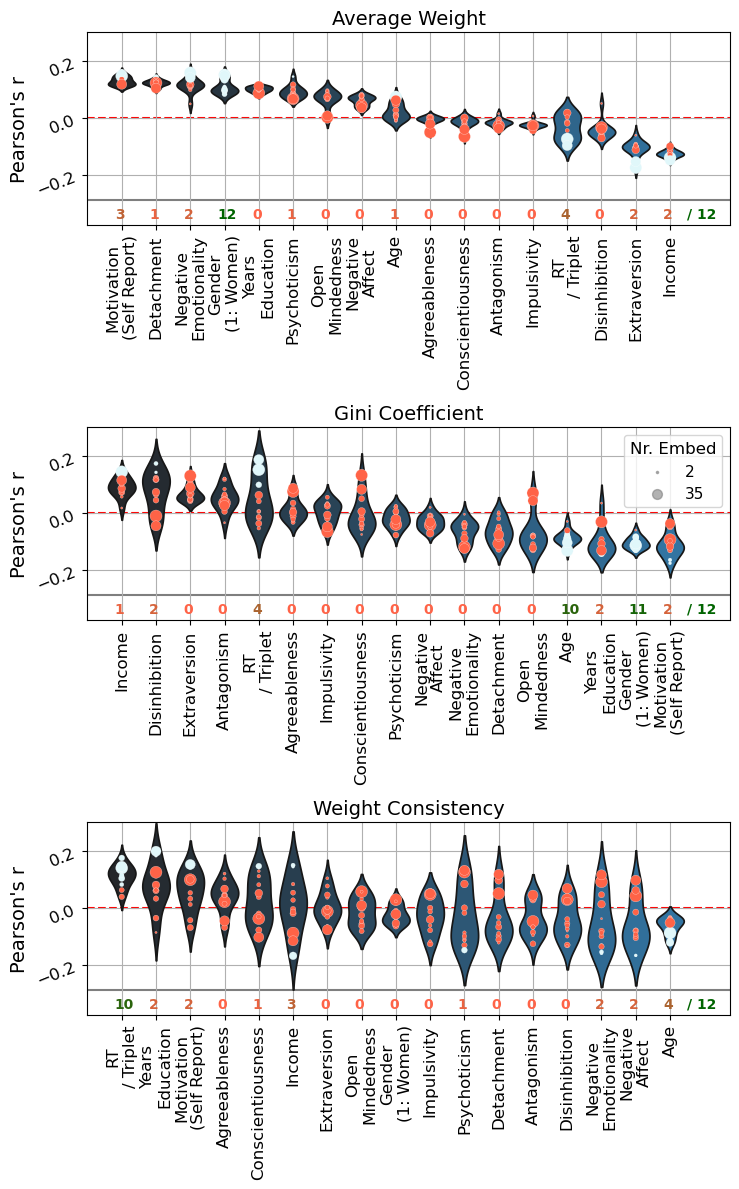

In [14]:
f, axes = plt.subplots(3, figsize=(7.5, 12))
f, axes = ut.plot_cors_sumstat_violin(df_plt, f, axes)

plt.tight_layout()
f.savefig("documents/writeup/figures-plotting/qs-dems-correlations.pdf")

# Hyperparameter Search

In [83]:
tbl_plt2 = pd.read_pickle("highdim-plot-data.pkl")

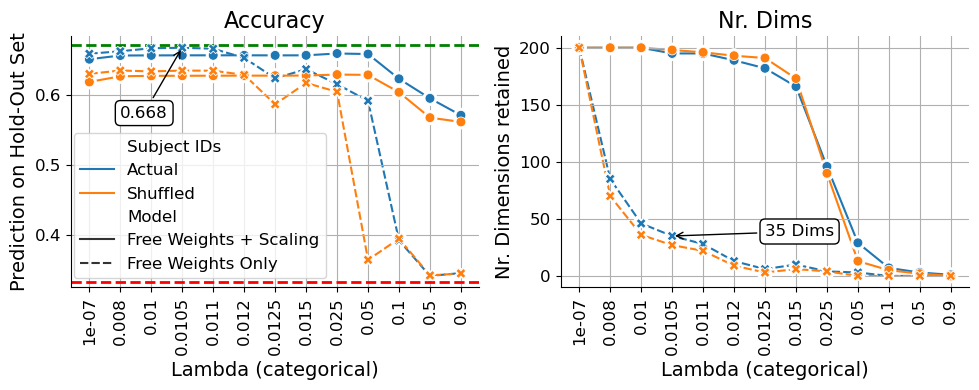

In [87]:
g = sns.FacetGrid(data=tbl_plt2, col="variable", col_wrap=2, sharey=False, height=4, aspect=1.25)
g = ut.plot_hyp_search(g, tbl_plt2)
g.savefig("documents/writeup/figures-plotting/accuracy-benefit.pdf")

# Mappability

In [93]:
df_cors = pd.read_pickle("data/dataframes-plotting-ms/mappability.pkl")

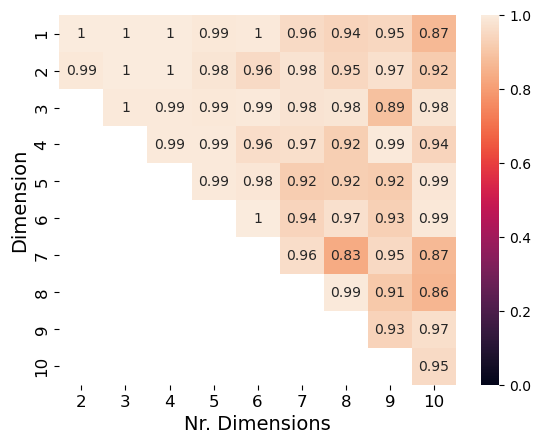

In [95]:
range_dims = [i for i in range(2, 11)] + [15, 25, 35]

f, ax = plt.subplots(1)

df_cors_mappable = df_cors[[d for d in range_dims if d < 15]].loc[1:10,:]
sns.heatmap(df_cors_mappable, annot=True, mask=df_cors_mappable.isna(), vmin=0, vmax=1, ax=ax)
ax.set_title(ax.get_title(), fontsize=16)
ax.set_xlabel(ax.get_xlabel(), fontsize=14)
ax.set_ylabel(ax.get_ylabel(), fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.set_ylabel("Dimension")
_ = ax.set_xlabel("Nr. Dimensions")

f.savefig("documents/writeup/figures-plotting/mappability.pdf")

# Model Deltas

In [96]:
df_triplets_study = pd.read_csv("data/dataframes-plotting-ms/triplets_study.csv")
df_items_delta = pd.read_csv("data/dataframes-plotting-ms/triplets_all.csv")

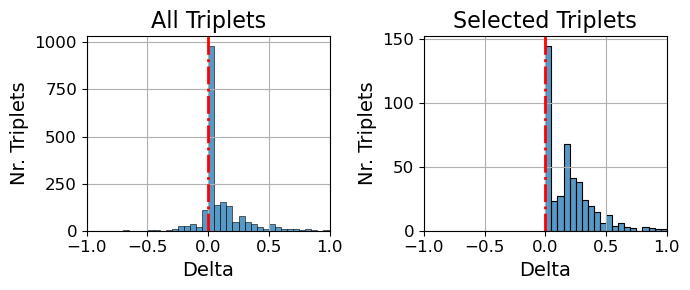

In [97]:
f, axes = plt.subplots(1, 2, figsize=(7, 3))

sns.histplot(data=df_triplets_study.rename(columns={'delta': 'Delta'}), x="Delta", binwidth=.05, ax = axes[1])
sns.histplot(data=df_items_delta, x="delta", binwidth=.05, ax = axes[0])
axes[0].set_title("All Triplets")
axes[1].set_title("Selected Triplets")

for ax in axes:
    ax.set_title(ax.get_title(), fontsize=16)
    ax.set_xlabel("Delta", fontsize=14)
    ax.set_ylabel("Nr. Triplets", fontsize=14)
    ax.axvline(x=0, color="red", linestyle="-.", linewidth=2)
    ax.set_xlim((-1, 1))
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True)

plt.tight_layout()
f.savefig("documents/writeup/figures-plotting/model-delta-histograms.pdf")